01.YOLO V4 https://github.com/WongKinYiu/PyTorch_YOLOv4

  https://ai.iias.sinica.edu.tw/yolov4yolov7-developing-process-minutes/

  論文發表: 有

  主要貢獻: 整合了當時各種提升目標檢測效能的技巧，形成一個強大的基準模型。

  網絡架構:

  Backbone: CSPDarknet53

  Neck: SPP, PAN

  Head: YOLOv3 Head

  數據增強: Mosaic, CutMix

  Loss 函數: CIoU Loss

  其他: Mish 激活函數, DropBlock 正則化, SAM

02.YOLO V5 https://www.ultralytics.com

  論文發表: 無

  主要貢獻: 繼承 YOLOv4 的優點，並簡化架構和訓練流程，提高效率。提供不同大小的模型版本 (s/m/l/x)，方便部署。

  網絡架構:

  Backbone: CSPDarknet53 (與 V4 相同)

  Neck: PAN (與 V4 相同)

  Head: YOLOv3 Head (與 V4 相同)

  數據增強: Mosaic

  Loss 函數: CIoU Loss, BCEWithLogitsLoss

  其他: Auto Anchor, 加强版正负样本匹配策略

03.YOLO V7 https://github.com/WongKinYiu/yolov7

  論文發表: 有

  主要貢獻: 在 YOLOv4 和 YOLOv5 的基礎上，進一步提升模型架構和訓練策略，達到更高的精度和速度。

  網絡架構:

  Backbone: 不再使用 Darknet 网络，採用新的架構設計

  Neck: 新的 feature map 融合策略

  Head: 改进的 head 结构

  Loss 函數: 改进的 loss 計算方式

  其他: 新的標籤分配策略，模型缩放策略

04.YOLO V8 https://www.ultralytics.com

  論文發表: 無

  主要貢獻: 與 YOLOv5 同一開發團隊，簡化架構，提升訓練和推理速度。

  網絡架構:

  Backbone: CSP 结构，使用 C2f 模块替换部分 C3 模块

  Neck: 使用 C2f 模块替换部分 C3 模块

  Head: Decoupled-Head

  Loss 函數: DFL Loss + CIoU Loss, BCEWithLogitsLoss

  其他: Anchor-Free, 使用 assigner 比對 ground truth 和 prediction, 新的數據增強策略

05.重點補充:

  YOLOv4 奠定了現代 YOLO 系列的基礎，整合許多有效技巧。

  YOLOv5 强调易用性和效率，提供多种模型大小选择。

  YOLOv7 进一步提升了模型架构和训练策略，追求更高的精度和速度。

  YOLOv8 简化架构，追求更高的训练和推理速度。

###**Reference:**
01. a-history-of-vision-models
https://www.ultralytics.com/blog/a-history-of-vision-models

02. mean-average-precision https://www.digitalocean.com/community/tutorials/mean-average-precision

03. quick start https://docs.ultralytics.com/quickstart/

04. gemini-bounding-box-visualization https://simonwillison.net/2024/Aug/26/gemini-bounding-box-visualization/

05. Labelimg and Makesense:

  https://blog.csdn.net/weixin_41010198/article/details/106378404

  https://blog.csdn.net/weixin_45192980/article/details/119338209

06. Real-time Object Tracking with OpenCV and YOLOv8 in Python

  https://www.thepythoncode.com/article/real-time-object-tracking-with-yolov8-opencv

  https://github.com/python-dontrepeatyourself/Real-time-Object-Tracking-with-DeepSORT-and-YOLOv8

##**pip install ultralytics**

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.2 MB/s eta 0:00:00


In [4]:
# Edit -> Notebook settings -> Hardware accelerator: GPU -> Save
!nvidia-smi

Wed Feb 11 08:36:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


In [6]:
from ultralytics import YOLO
from IPython.display import display, Image

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!ls /content/drive/MyDrive/yolo/data

appleorange.zip  FaceMaskDataset.zip  plate.zip
catdog.zip	 mango.zip	      test.mp4


In [9]:
# copy over the dataset into the root directory of the Colab VM

# !cp /content/drive/MyDrive/yolo/data/FaceMaskDataset.zip /content
!cp /content/drive/MyDrive/yolo/data/appleorange.zip /content

In [10]:
# unzip the dataset and the contents so that they are now in /content folder

# !unzip /content/FaceMaskDataset.zip -d /content/
!unzip /content/appleorange.zip -d /content/

Archive:  /content/appleorange.zip
   creating: /content/appleorange/
   creating: /content/appleorange/images/
   creating: /content/appleorange/images/train/
  inflating: /content/appleorange/images/train/11160eb67d2a15e3.jpg  
  inflating: /content/appleorange/images/train/03850e1830a76683.jpg  
  inflating: /content/appleorange/images/train/f18cd6a3357a4b4c.jpg  
  inflating: /content/appleorange/images/train/2c2260828ab5891d.jpg  
  inflating: /content/appleorange/images/train/15f908c12e4954ac.jpg  
  inflating: /content/appleorange/images/train/a963d6f4ab1fff27.jpg  
  inflating: /content/appleorange/images/train/c4dc8f6142c188e7.jpg  
  inflating: /content/appleorange/images/train/a0c0f3a12681dff9.jpg  
  inflating: /content/appleorange/images/train/05f7b854aee7824b.jpg  
  inflating: /content/appleorange/images/train/067664613388e55e.jpg  
  inflating: /content/appleorange/images/train/a351d80631ae26bb.jpg  
  inflating: /content/appleorange/images/train/6b179b76bb1a82b1.jpg  


##**One class**

***建立 plate.yaml***

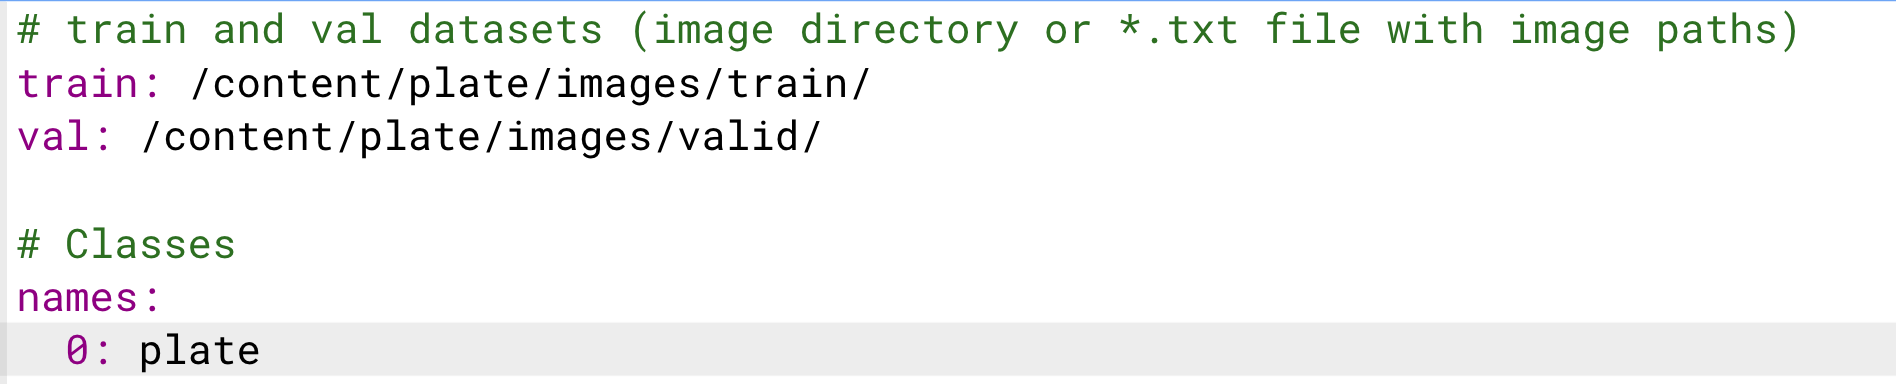



##**Multi-classes**

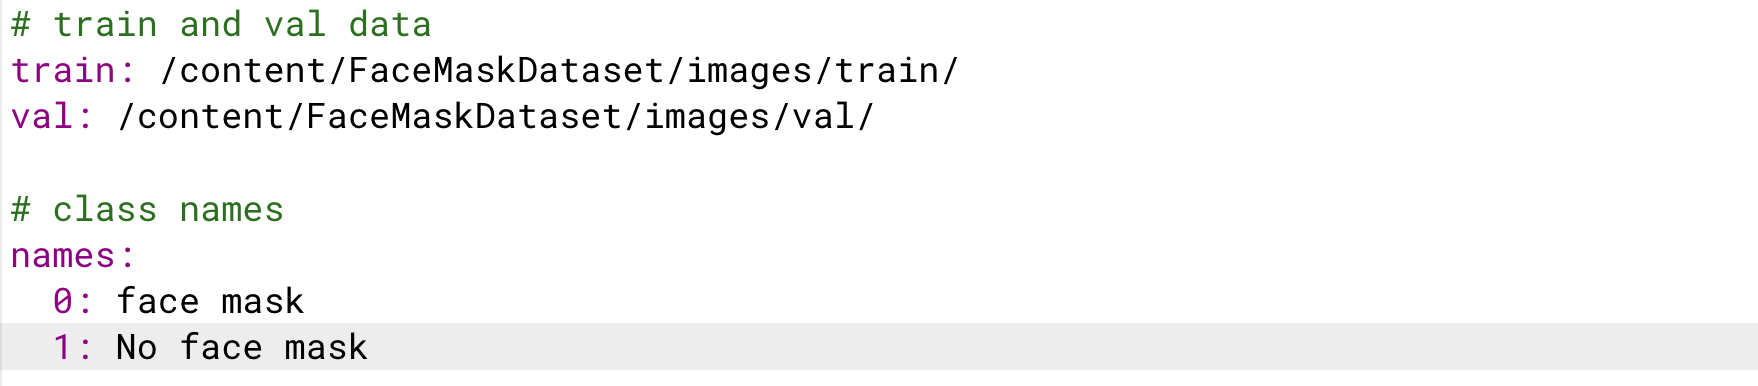

##**train custom data**

In [11]:
# https://docs.ultralytics.com/usage/cli/
# https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb

# data: yaml file to define path to data, classes' names
# model: yolov8x.pt yolov8l.pt yolov8m.pt yolov8s.pt yolov8n.pt
# a full list of train arguments: https://docs.ultralytics.com/usage/cfg/

# !yolo task=detect mode=train model=yolov8s.pt data=/content/drive/MyDrive/yolo/yolo_v8/mask.yaml epochs=50 patience=10 imgsz=400 plots=True
!yolo task=detect mode=train model=yolov8s.pt data=/content/drive/MyDrive/yolo/yolo_v8/apl.yaml epochs=5 patience=10 imgsz=400 plots=True

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo/yolo_v8/apl.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10,

In [12]:
## To save model weights to your google drive!

# !cp '/content/runs/detect/train/weights/best.pt' /content/drive/MyDrive/yolo/yolo_v8/
# !cp '/content/runs/detect/train/weights/last.pt' /content/drive/MyDrive/yolo/yolo_v8/

In [13]:
# check training metrics:
# /content/runs/detect/train/results.png
# /content/runs/detect/train/confusion_matrix.png

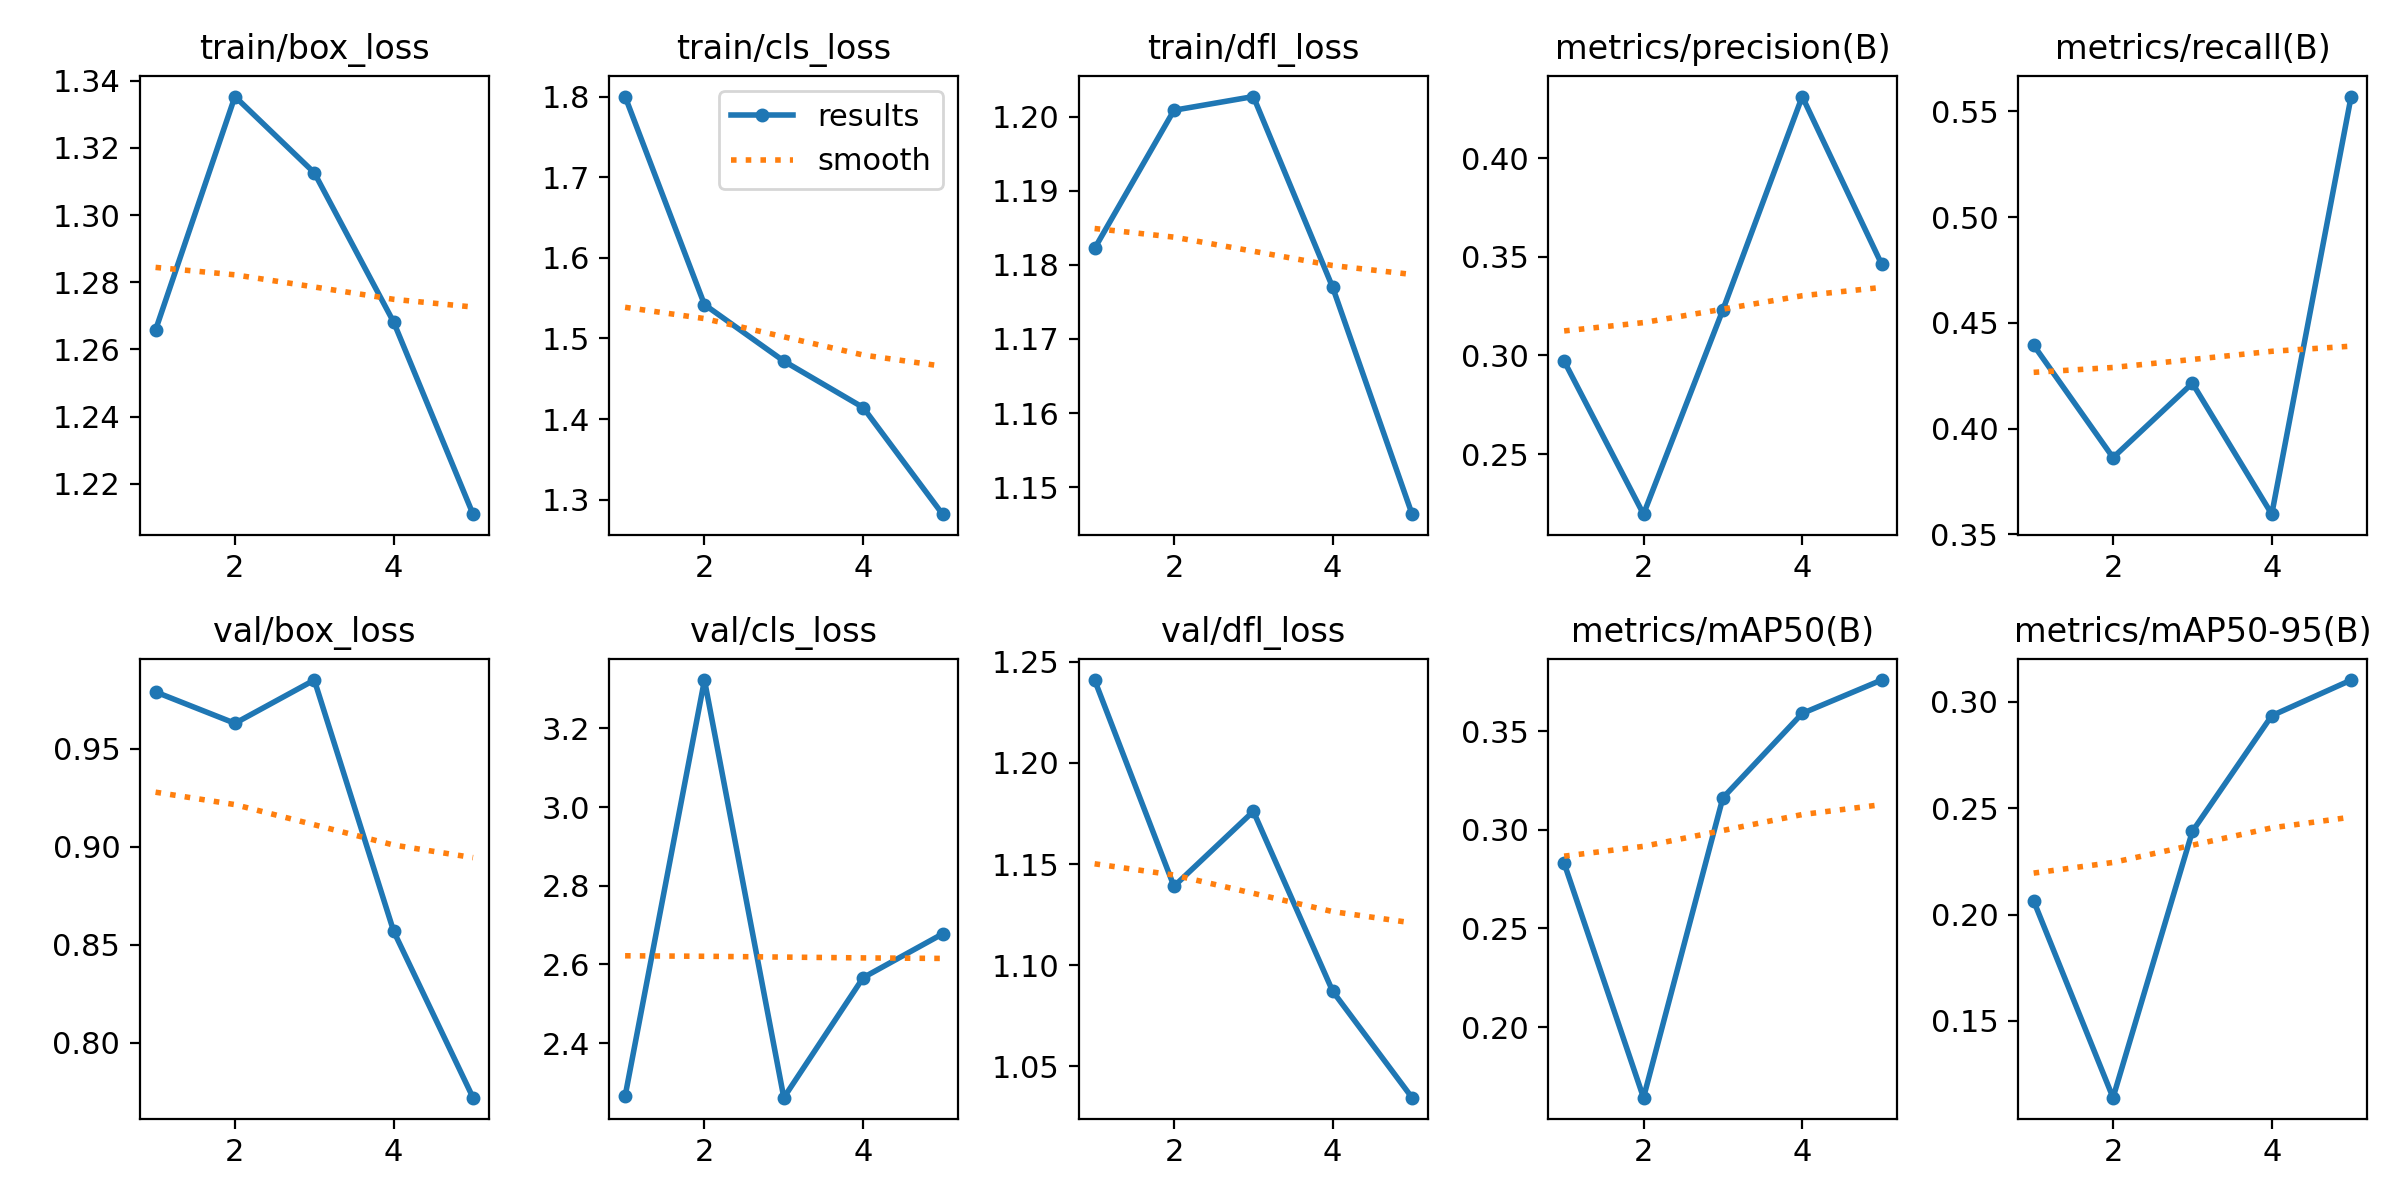

In [14]:
Image(filename='/content/runs/detect/train/results.png', width=600)

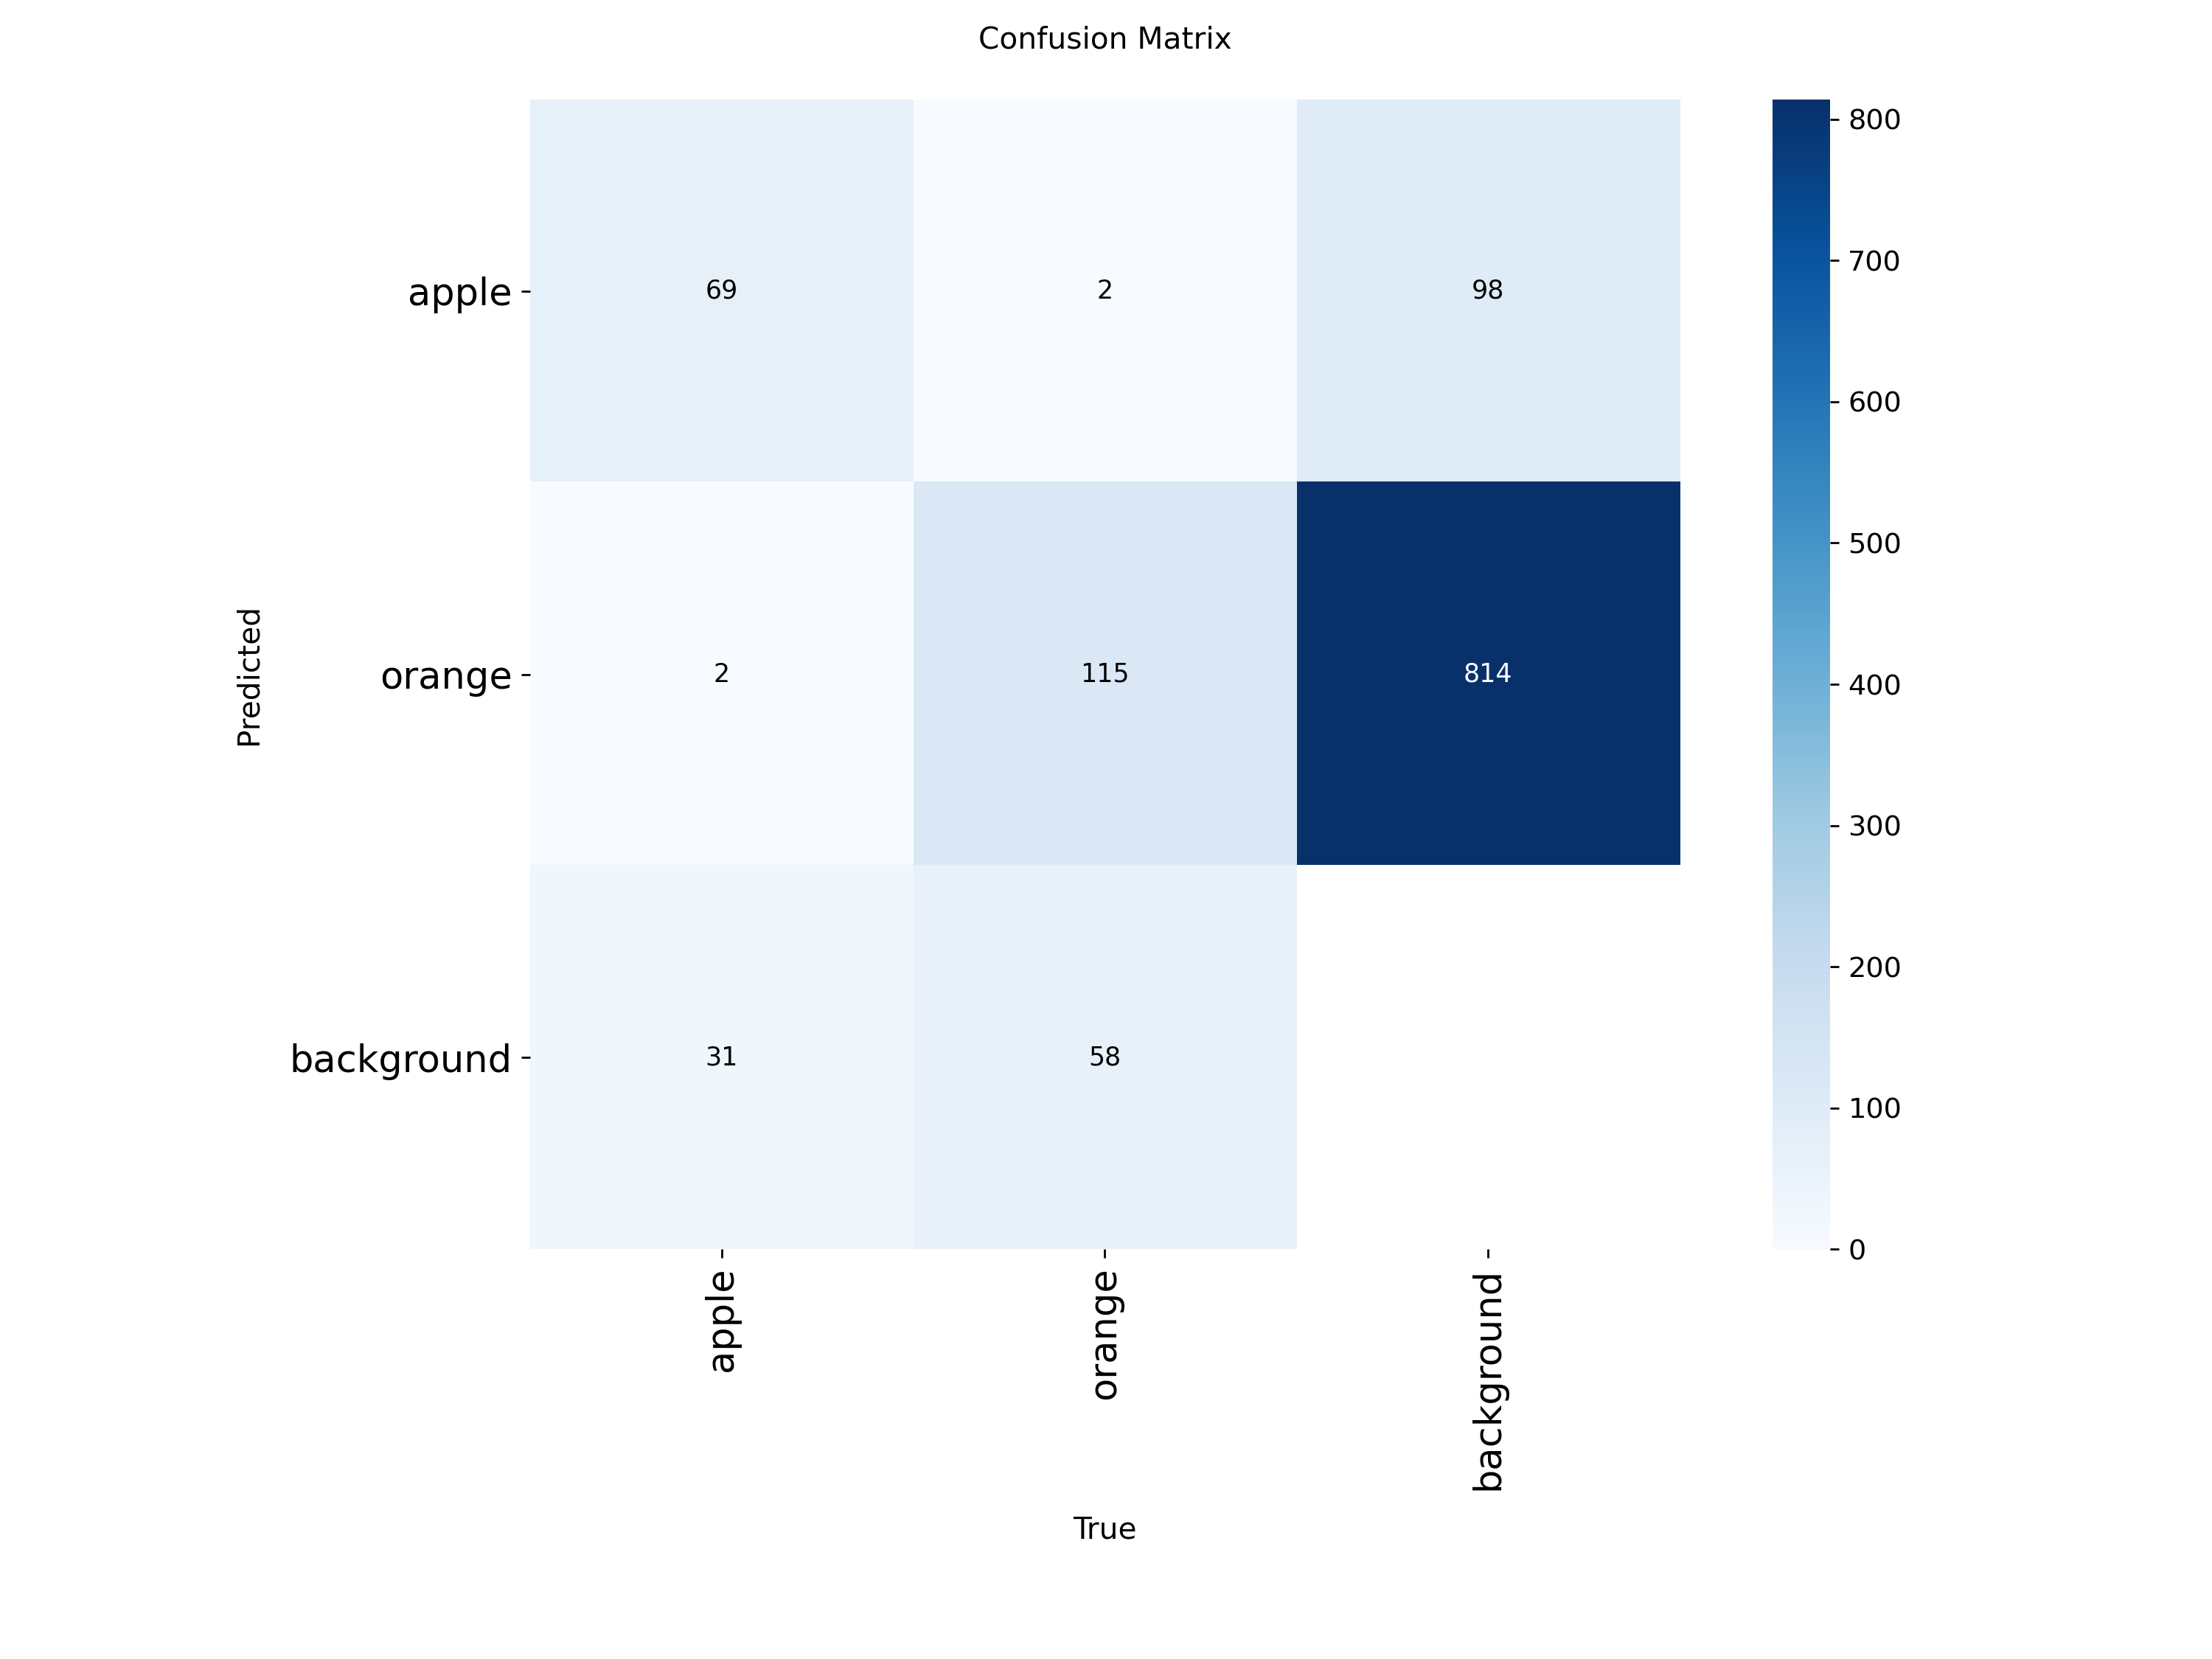

In [15]:
Image(filename='/content/runs/detect/train/confusion_matrix.png', width=600)

##**inference on test data**

In [16]:
# 1. CLI Command Line Interface

In [17]:
# a full list of predict arguments: https://docs.ultralytics.com/usage/cfg/
# 預設 conf=0.25, iou=0.7

# !yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source=/content/drive/MyDrive/yolo/yolo_v8/mask.jpg save=True
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source=/content/drive/MyDrive/yolo/yolo_v8/app_ora.jpg save=True

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/drive/MyDrive/yolo/yolo_v8/app_ora.jpg: 256x416 3 apples, 5 oranges, 43.4ms
Speed: 1.5ms preprocess, 43.4ms inference, 16.7ms postprocess per image at shape (1, 3, 256, 416)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


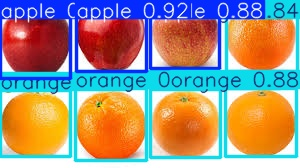

In [18]:
# display(Image(filename='/content/runs/detect/predict/mask.jpg', width=600))
display(Image(filename='/content/runs/detect/predict/app_ora.jpg', width=600))

In [19]:
# 2. SDK Software Development Kit

In [20]:
model = YOLO('/content/runs/detect/train/weights/best.pt')

# results = model.predict(source='/content/drive/MyDrive/yolo/yolo_v8/mask.jpg', conf=0.25)
results = model.predict(source='/content/drive/MyDrive/yolo/yolo_v8/app_ora.jpg', conf=0.25)


image 1/1 /content/drive/MyDrive/yolo/yolo_v8/app_ora.jpg: 256x416 3 apples, 5 oranges, 70.4ms
Speed: 4.5ms preprocess, 70.4ms inference, 22.5ms postprocess per image at shape (1, 3, 256, 416)


In [21]:
# detected boxes' coordinates tensors
results[0].boxes.xyxy # [xmin,ymin,xmax,ymax]

tensor([[7.6103e+01, 0.0000e+00, 1.4643e+02, 7.1893e+01],
        [1.4772e-01, 3.5312e-01, 7.0406e+01, 7.8107e+01],
        [2.2516e+02, 8.8289e+01, 2.9618e+02, 1.5621e+02],
        [1.5049e+02, 9.1121e-01, 2.1927e+02, 6.8758e+01],
        [7.5862e+01, 8.8839e+01, 1.4650e+02, 1.6075e+02],
        [9.3345e-01, 9.0591e+01, 7.0826e+01, 1.5681e+02],
        [2.2648e+02, 2.4989e-01, 2.9748e+02, 7.1066e+01],
        [1.5006e+02, 8.9041e+01, 2.2027e+02, 1.5775e+02]], device='cuda:0')

In [22]:
# detected boxes' coordinates arrays
results[0].boxes.xyxy.detach().cpu().numpy()

array([[     76.103,           0,      146.43,      71.893],
       [    0.14772,     0.35312,      70.406,      78.107],
       [     225.16,      88.289,      296.18,      156.21],
       [     150.49,     0.91121,      219.27,      68.758],
       [     75.862,      88.839,       146.5,      160.75],
       [    0.93345,      90.591,      70.826,      156.81],
       [     226.48,     0.24989,      297.48,      71.066],
       [     150.06,      89.041,      220.27,      157.75]], dtype=float32)

In [23]:
# confidence values
results[0].boxes.conf.detach().cpu().numpy()

array([    0.92346,     0.91557,     0.88492,     0.87771,     0.87019,     0.84225,     0.83893,     0.83319], dtype=float32)

In [24]:
# classes
results[0].boxes.cls.detach().cpu().numpy()

array([          0,           0,           1,           0,           1,           1,           1,           1], dtype=float32)

In [27]:
# local video path or youtube video link

#!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source=/content/drive/MyDrive/yolo/data/test.mp4 save=True

!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source=/content/drive/MyDrive/yolo/yolo_v8/apple.mp4 save=True

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

video 1/1 (frame 1/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 44.2ms
video 1/1 (frame 2/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 8.1ms
video 1/1 (frame 3/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 7.9ms
video 1/1 (frame 4/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 7.9ms
video 1/1 (frame 5/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 7.9ms
video 1/1 (frame 6/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 8.0ms
video 1/1 (frame 7/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 8.1ms
video 1/1 (frame 8/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416x256 2 apples, 8.0ms
video 1/1 (frame 9/194) /content/drive/MyDrive/yolo/yolo_v8/apple.mp4: 416

In [28]:
!cp /content/runs/detect/predict2/apple.avi /content/drive/MyDrive/yolo/yolo_v8/



---


---



## Exer 1. 使用 mask.zip 及 mask.yaml 訓練偵測模型

## Exer 2. 下載 Apple Orange 二類圖片,訓練偵測模型